In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [36]:
df = pd.read_csv("covid_excess_mortality.csv")

print(df.head())

  location        date  p_scores_all_ages
0  Albania  2020-01-31             -10.65
1  Albania  2020-02-29               2.17
2  Albania  2020-03-31               0.62
3  Albania  2020-04-30               3.23
4  Albania  2020-05-31               6.15


In [37]:
df = pd.read_csv("covid_excess_mortality.csv")

cleaned_locations = df['location'].str.strip().str.lower()

filtered_df = df[cleaned_locations == 'india'].copy()

if filtered_df.empty:
    print("Warning: No data found for 'India' after robust filtering. Falling back to 'Albania' for demonstration purposes.")
    print("You can inspect available locations by running `df['location'].unique()`.")
    df = df[cleaned_locations == 'albania'].copy()
else:
    df = filtered_df

print(f"DataFrame for location '{df['location'].iloc[0]}' (first 5 rows):")
print(df.head())

You can inspect available locations by running `df['location'].unique()`.
DataFrame for location 'Albania' (first 5 rows):
  location        date  p_scores_all_ages
0  Albania  2020-01-31             -10.65
1  Albania  2020-02-29               2.17
2  Albania  2020-03-31               0.62
3  Albania  2020-04-30               3.23
4  Albania  2020-05-31               6.15


In [38]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df = df.set_index('date') # Explicitly reassign after setting index
print(df.head())

           location  p_scores_all_ages
date                                  
2020-01-31  Albania             -10.65
2020-02-29  Albania               2.17
2020-03-31  Albania               0.62
2020-04-30  Albania               3.23
2020-05-31  Albania               6.15


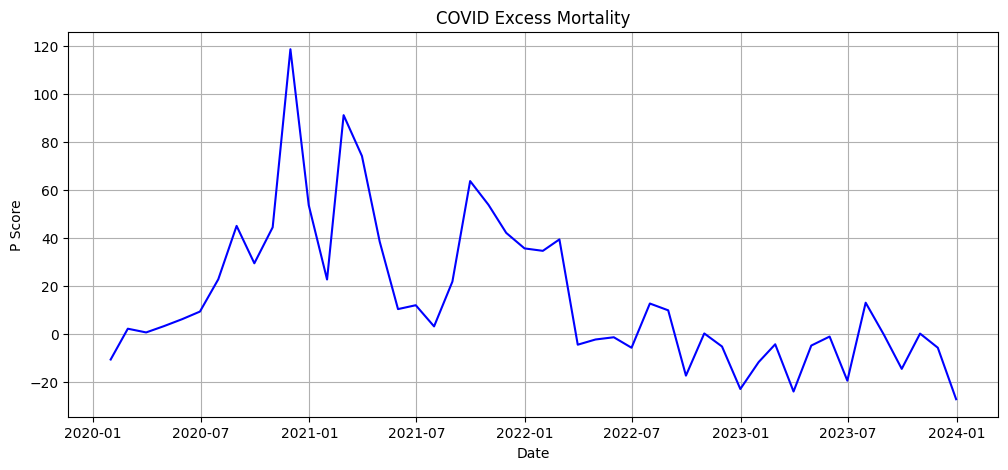

In [39]:
plt.figure(figsize=(12,5))

plt.plot(df['p_scores_all_ages'], color='blue')

plt.title("COVID Excess Mortality")

plt.xlabel("Date")

plt.ylabel("P Score")

plt.grid(True)

plt.show()

In [40]:
#Check Stationarity (ADF Test)
result = adfuller(df['p_scores_all_ages'].dropna())

print("ADF Statistic :", result[0])

print("P Value :", result[1])

if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

ADF Statistic : -1.2940941816424436
P Value : 0.6318698827462099
Data is Non-Stationary


In [41]:
# Drop rows with NaN values in 'p_scores_all_ages' before splitting
df_cleaned = df.dropna(subset=['p_scores_all_ages'])

train = df_cleaned.iloc[:int(len(df_cleaned)*0.8)]
test = df_cleaned.iloc[int(len(df_cleaned)*0.8):]

print(f"Train set length: {len(train)}")
print(f"Test set length: {len(test)}")
print("Test set head (p_scores_all_ages):\n", test['p_scores_all_ages'].head())

Train set length: 38
Test set length: 10
Test set head (p_scores_all_ages):
 date
2023-03-31   -23.97
2023-04-30    -4.84
2023-05-31    -1.10
2023-06-30   -19.45
2023-07-31    12.99
Name: p_scores_all_ages, dtype: float64


In [42]:
#Apply ARIMA
model = ARIMA(train['p_scores_all_ages'], order=(2,1,2))

model_fit = model.fit()

forecast = model_fit.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


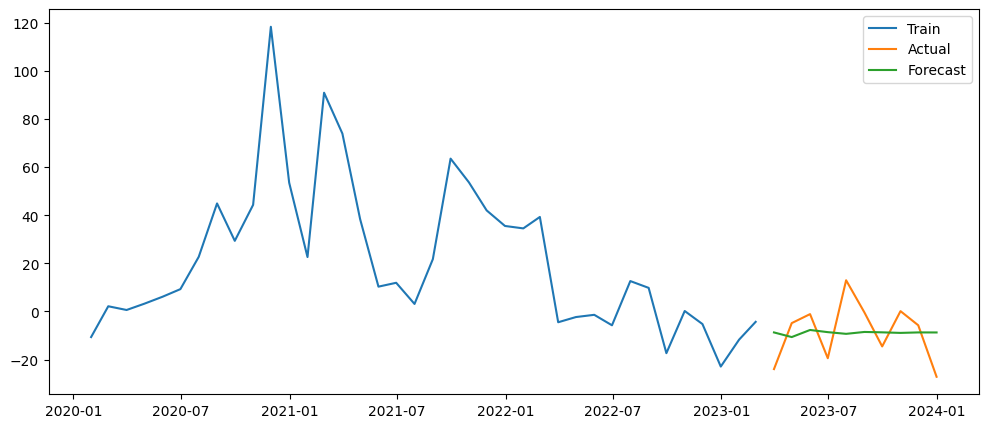

In [43]:
plt.figure(figsize=(12,5))

plt.plot(train.index,
         train['p_scores_all_ages'],
         label="Train")

plt.plot(test.index,
         test['p_scores_all_ages'],
         label="Actual")

plt.plot(test.index,
         forecast,
         label="Forecast")

plt.legend()

plt.show()

In [44]:
actual_test_values = test['p_scores_all_ages']

# Drop NaN values from actual_test_values and get the corresponding indices
valid_indices = actual_test_values.dropna().index

if valid_indices.empty:
    print("Error: The 'test' set's 'p_scores_all_ages' column contains no non-NaN values to compare against the forecast.")
    print("Please ensure your 'test' set has actual observed values for calculating metrics.")
    rmse = np.nan
    mae = np.nan
else:
    # Align the forecast with the actual test values that are not NaN
    aligned_actual = actual_test_values.loc[valid_indices]
    aligned_forecast = forecast.loc[valid_indices]

    rmse = np.sqrt(mean_squared_error(aligned_actual, aligned_forecast))
    mae = mean_absolute_error(aligned_actual, aligned_forecast)

print("RMSE =", rmse)
print("MAE =", mae)

RMSE = 12.064167383836809
MAE = 10.522662862165626


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


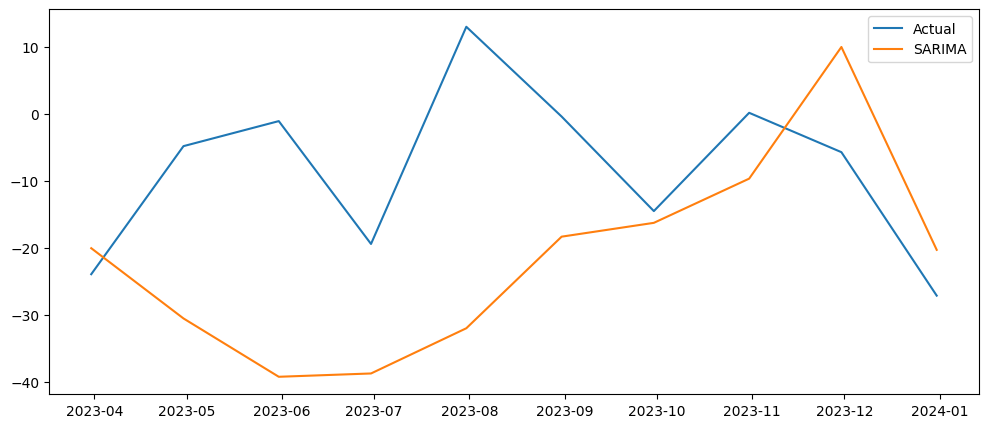

SARIMA RMSE = 22.920413418966213
SARIMA MAE = 18.427353548217173


In [45]:
# Apply SARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(train['p_scores_all_ages'],

                 order=(1,1,1),

                 seasonal_order=(1,1,1,12))

sarima_fit = sarima.fit()

forecast = sarima_fit.forecast(len(test))

plt.figure(figsize=(12,5))

plt.plot(test.index,
         test['p_scores_all_ages'],
         label="Actual")

plt.plot(test.index,
         forecast,
         label="SARIMA")

plt.legend()

plt.show()

rmse = np.sqrt(mean_squared_error(test['p_scores_all_ages'], forecast))

mae = mean_absolute_error(test['p_scores_all_ages'], forecast)

print("SARIMA RMSE =", rmse)

print("SARIMA MAE =", mae)